# Task 02 — Visualise an Eigenvector Under Transformation

The goal is to visually demonstrate the difference between an
eigenvector and a normal vector under a matrix transformation.

For an eigenvector:

Av = λv

This means the eigenvector stays on its original line and is only
stretched or reversed.

For a normal vector, the matrix can change both its direction and
magnitude.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Transformation matrix
A = np.array([
    [3., 1.],
    [1., 3.]
])

# Calculate eigenvalues and eigenvectors
vals, vecs = np.linalg.eig(A)

print("Matrix A:")
print(A)

print("\nEigenvalues:")
print(vals)

print("\nEigenvectors:")
print(vecs)

Matrix A:
[[3. 1.]
 [1. 3.]]

Eigenvalues:
[4.+0.j 2.+0.j]

Eigenvectors:
[[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]


In [3]:
# Choose the first eigenvector
ev = vecs[:, 0]

# Choose a normal vector that is NOT an eigenvector
normal = np.array([1., 0.3])

# Transform both vectors
ev_transformed = A @ ev
normal_transformed = A @ normal

print("Eigenvector:")
print(ev)

print("\nTransformed eigenvector:")
print(ev_transformed)

print("\nNormal vector:")
print(normal)

print("\nTransformed normal vector:")
print(normal_transformed)

Eigenvector:
[0.70710678+0.j 0.70710678+0.j]

Transformed eigenvector:
[2.82842712+0.j 2.82842712+0.j]

Normal vector:
[1.  0.3]

Transformed normal vector:
[3.3 1.9]


In [4]:
# Eigenvalue corresponding to the selected eigenvector
eigenvalue = vals[0]

print("Selected eigenvalue:", eigenvalue)

Selected eigenvalue: (4+0j)


d:\AI ML Internship\.venv\Lib\site-packages\matplotlib\transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


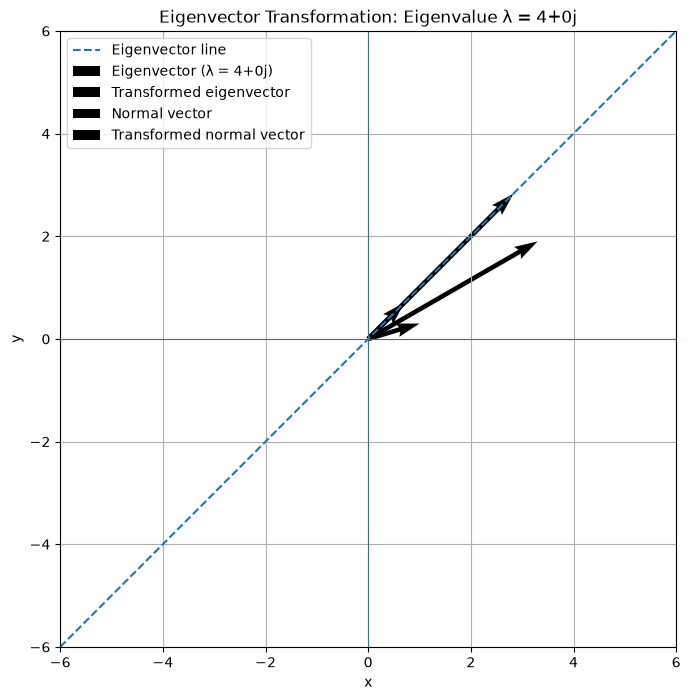

In [5]:
plt.figure(figsize=(10, 8))

# Plot the eigenvector's line in both directions
line_length = 6

line_x = np.linspace(-line_length, line_length, 100)
line_y = line_x

plt.plot(
    line_x,
    line_y,
    linestyle="--",
    label="Eigenvector line"
)

# Original eigenvector
plt.quiver(
    0, 0,
    ev[0], ev[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label=f"Eigenvector (λ = {eigenvalue:.0f})"
)

# Transformed eigenvector
plt.quiver(
    0, 0,
    ev_transformed[0],
    ev_transformed[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="Transformed eigenvector"
)

# Original normal vector
plt.quiver(
    0, 0,
    normal[0],
    normal[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="Normal vector"
)

# Transformed normal vector
plt.quiver(
    0, 0,
    normal_transformed[0],
    normal_transformed[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="Transformed normal vector"
)

# Axis settings
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlim(-6, 6)
plt.ylim(-6, 6)

plt.xlabel("x")
plt.ylabel("y")

plt.title(
    f"Eigenvector Transformation: Eigenvalue λ = {eigenvalue:.0f}"
)

plt.grid(True)
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")

plt.show()

In [6]:
print("===== EIGENVECTOR VERIFICATION =====")

print("A @ ev:")
print(A @ ev)

print("\nλ * ev:")
print(eigenvalue * ev)

print("\nDoes Av = λv?")
print(np.allclose(A @ ev, eigenvalue * ev))

===== EIGENVECTOR VERIFICATION =====
A @ ev:
[2.82842712+0.j 2.82842712+0.j]

λ * ev:
[2.82842712+0.j 2.82842712+0.j]

Does Av = λv?
True


In [7]:
print("===== NORMAL VECTOR CHECK =====")

# Check whether A @ normal is a scalar multiple of normal
normal_ratio = normal_transformed / normal

print("Normal vector:")
print(normal)

print("\nTransformed normal vector:")
print(normal_transformed)

print("\nComponent ratios:")
print(normal_ratio)

===== NORMAL VECTOR CHECK =====
Normal vector:
[1.  0.3]

Transformed normal vector:
[3.3 1.9]

Component ratios:
[3.3        6.33333333]


In [ ]:
## Questions

### 1. How can you tell, just by looking at the plot, which vector is the eigenvector?

The eigenvector and its transformed version lie on the same straight
line. The transformed eigenvector only changes its length.

The normal vector and its transformed version point in different
directions, so the normal vector does not stay on its original line.

Therefore, the vector that stays on the same line is the eigenvector.

---

### 2. What does the eigenvalue's sign do to the transformed eigenvector's direction?

If λ > 0, the transformed eigenvector points in the same direction.

If λ < 0, the transformed eigenvector points in the opposite
direction because the vector is multiplied by a negative number.

For example:

Av = 3v

keeps the direction.

But:

Av = -3v

reverses the direction while stretching it by a factor of 3.

---

### 3. If an eigenvalue were exactly 1, what would happen to its eigenvector?

If:

Av = 1v

then:

Av = v

The eigenvector would remain exactly unchanged.

Its direction and magnitude would both stay the same.

Therefore, λ = 1 means the transformation leaves that eigenvector
unchanged.

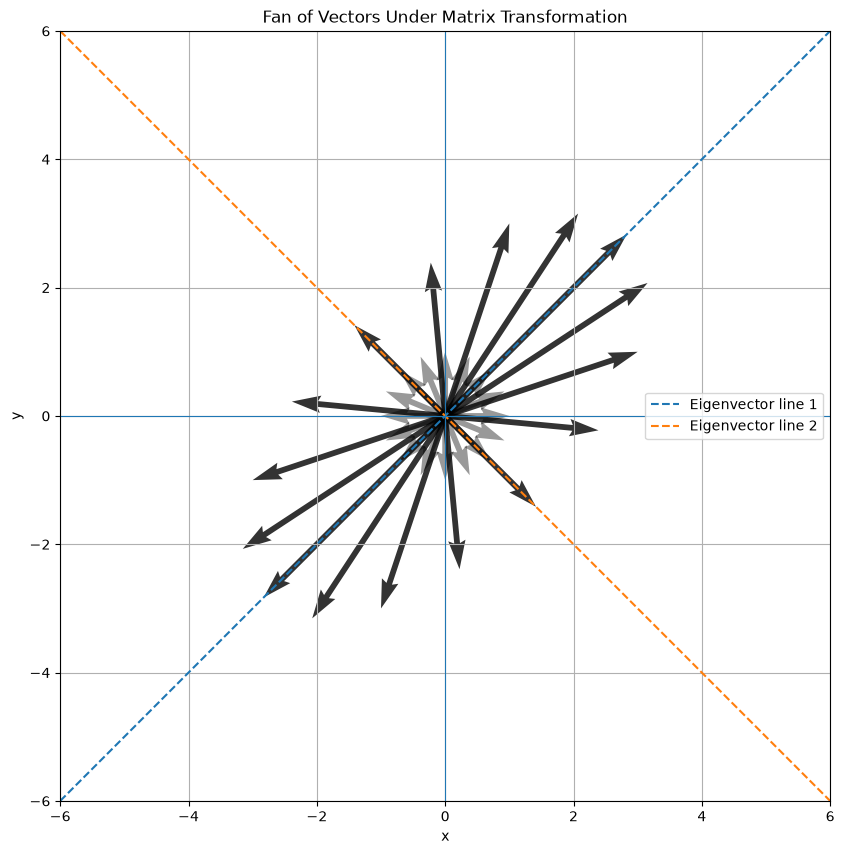

In [8]:
# Create many vectors at different angles
angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)

vectors = np.array([
    [np.cos(angle), np.sin(angle)]
    for angle in angles
])

# Transform all vectors
transformed_vectors = vectors @ A.T

plt.figure(figsize=(10, 10))

for i in range(len(vectors)):
    # Original vector
    plt.quiver(
        0, 0,
        vectors[i, 0],
        vectors[i, 1],
        angles="xy",
        scale_units="xy",
        scale=1,
        alpha=0.4
    )

    # Transformed vector
    plt.quiver(
        0, 0,
        transformed_vectors[i, 0],
        transformed_vectors[i, 1],
        angles="xy",
        scale_units="xy",
        scale=1,
        alpha=0.8
    )

# Plot both eigenvector lines
x = np.linspace(-6, 6, 100)

plt.plot(x, x, linestyle="--", label="Eigenvector line 1")
plt.plot(x, -x, linestyle="--", label="Eigenvector line 2")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlim(-6, 6)
plt.ylim(-6, 6)

plt.xlabel("x")
plt.ylabel("y")

plt.title("Fan of Vectors Under Matrix Transformation")

plt.grid(True)
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")

plt.show()